In [1]:
%cd ..
%ls

/home/suetin/Projects/Interview
data/        main.py  notebooks/  requirements.txt  tests/
example.png  models/  README.md   src/


In [2]:
import torch, os
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision.utils import make_grid

from src.dataset import ContrastiveDataset

In [3]:
# 
dataset = ContrastiveDataset(root_dir="data/flowers/", n_neg=3)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)

In [ ]:
batch = next(iter(loader))
orig = batch['anchor']
pos = batch['positive']
negs = batch['negatives']
labels = batch['class_idx']
orig.shape

torch.Size([32, 3, 224, 224])

In [5]:
pos.shape, negs.shape, labels

(torch.Size([32, 3, 224, 224]),
 torch.Size([32, 3, 3, 224, 224]),
 tensor([1, 1, 2, 0, 3, 3, 4, 4, 0, 1, 2, 2, 0, 1, 0, 4, 4, 3, 0, 1, 4, 3, 0, 2,
         0, 1, 0, 1, 0, 4, 3, 0]))

In [6]:
dataset.dataset.classes

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.1975338].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.9428324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.622571].


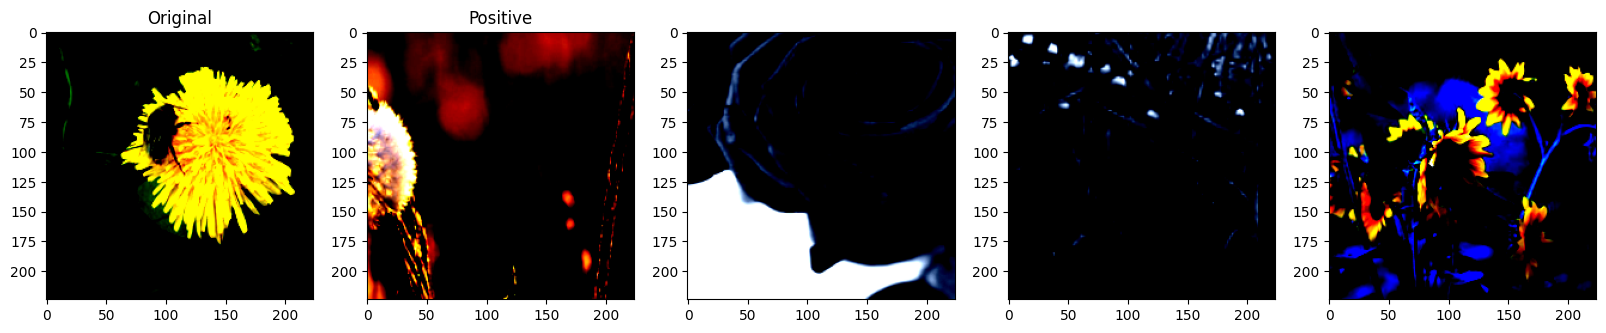

In [7]:
orig_img = orig[0].permute(1,2,0).numpy()
pos_img = pos[0].permute(1,2,0).numpy()
neg_1 = negs[0][0].permute(1,2,0).numpy()
neg_2 = negs[0][1].permute(1,2,0).numpy()
neg_3 = negs[0][2].permute(1,2,0).numpy()


plt.figure(figsize=(20,4))
plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(orig_img)
plt.subplot(1,5,2)
plt.title("Positive")
plt.imshow(pos_img)
plt.subplot(1,5,3)
plt.imshow(neg_1)
plt.subplot(1,5,4)
plt.imshow(neg_2)
plt.subplot(1,5,5)    
plt.imshow(neg_3);